# Fashion Dataset Exploration

This notebook explores the **Fashion Product Images** dataset.

Goals:
- Understand the dataset structure  
- Analyze available attributes  
- Visualize images and their labels  

## 1. Import Libraries

Import the required libraries for data handling and visualization.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 2. Define Dataset Paths

Set the paths to access the images and metadata.

In [2]:
data_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

image_folder = data_path + "/images"
csv_path = data_path + "/styles.csv"

## 3. Load Dataset

Load the CSV file containing product information.

In [3]:
df = pd.read_csv(csv_path, on_bad_lines='skip')

print("Número total de exemplos:", len(df))
df.head()

Número total de exemplos: 44424


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


## 4. Inspect Dataset Structure

Check the available columns to understand the dataset.

In [4]:
print(df.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


## 5. Data Cleaning

Select relevant attributes and remove missing values.

In [5]:
df = df[['id', 'articleType', 'baseColour', 'usage']]
df = df.dropna()

print("Depois de limpar:", len(df))

Depois de limpar: 44100


## 6. Image Path Mapping

Create the path for each image using its ID.

In [6]:
def get_image_path(img_id):
    return os.path.join(image_folder, str(img_id) + ".jpg")

df['image_path'] = df['id'].apply(get_image_path)

## 7. Validate Image Availability

Check if image files exist and remove invalid entries.

In [7]:
df['exists'] = df['image_path'].apply(os.path.exists)
df = df[df['exists'] == True]

print("After filtering missing images:", len(df))

After filtering missing images: 44095


## 8. Attribute Distribution

Analyze how attributes such as clothing type and color are distributed.

In [8]:
df['articleType'].value_counts().head(10)

articleType
Tshirts         7066
Shirts          3212
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64

In [9]:
df['baseColour'].value_counts().head(10)

baseColour
Black        9703
White        5498
Blue         4911
Brown        3441
Grey         2740
Red          2433
Green        2104
Pink         1824
Navy Blue    1784
Purple       1614
Name: count, dtype: int64

## 9. Visual Inspection

Display sample images along with their labels.

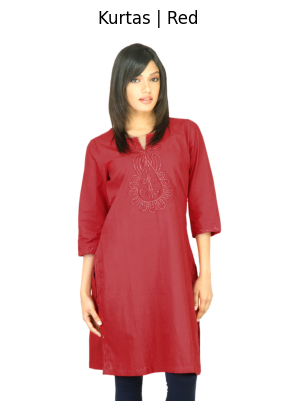

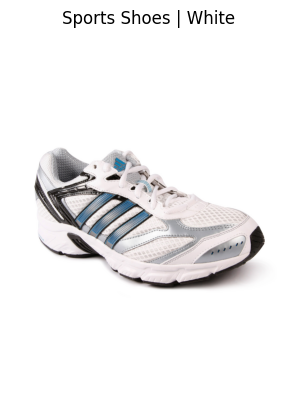

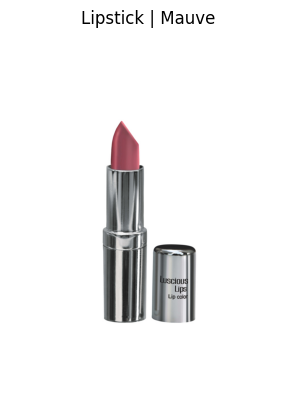

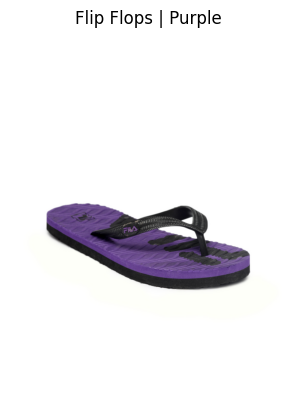

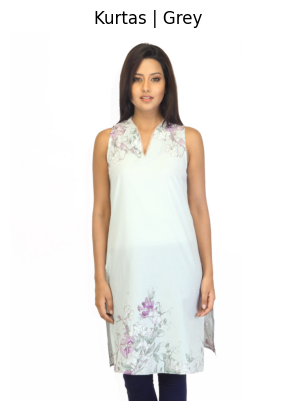

In [10]:
def show_samples(df, n=5):
    sample = df.sample(n)
    
    for _, row in sample.iterrows():
        img = Image.open(row['image_path'])
        
        plt.imshow(img)
        plt.title(f"{row['articleType']} | {row['baseColour']}")
        plt.axis("off")
        plt.show()

show_samples(df, 5)

## 10. Observations

- The dataset contains a wide variety of clothing types  
- Some categories appear much more frequently than others  
- The images are clear and consistent in quality  
- Some entries had missing information and were removed  
- The available attributes (type, color, usage) are enough to start building a model  

Overall, the dataset is suitable for developing an image classification model.